In [5]:
# sentence-transformers==5.1.2
# scikit-learn==1.6.1
# matplotlib==3.10.0
# numpy==2.0.2
# arxiv==2.2.0
# pandas==2.2.2
# cohere==5.20.0
# python-dotenv==1.1.1

!uv pip install sentence-transformers scikit-learn matplotlib numpy arxiv pandas cohere python-dotenv

Using Python 3.13.5 environment at: /Users/brooksjohnson/bbc_data_science/.venv
Resolved 65 packages in 709ms                                        
⠙ Preparing packages... (0/4)                                                   
⠙ Preparing packages... (0/4)--------------     0 B/20.25 KiB           
⠙ Preparing packages... (0/4)---------- 16.00 KiB/20.25 KiB         
⠙ Preparing packages... (0/4)---------- 16.00 KiB/20.25 KiB         
types-requests       ------------------------------ 16.00 KiB/20.25 KiB
⠙ Preparing packages... (0/4)--------------     0 B/977.15 KiB          
types-requests       ------------------------------ 20.25 KiB/20.25 KiB
⠙ Preparing packages... (0/4)--------------     0 B/977.15 KiB          
types-requests       ------------------------------ 20.25 KiB/20.25 KiB
⠙ Preparing packages... (0/4)--------------     0 B/977.15 KiB          
types-requests       ------------------------------ 20.25 KiB/20.25 KiB
⠙ Preparing packages... (0/4)-------------- 16.00 K

In [6]:
import arxiv

### Create the arXiv client once and reuse it
### This is recommended by the arxiv package to respect rate limits
client = arxiv.Client()

def collect_arxiv_papers(category, max_results=100):
    """
    Collect papers from arXiv by category.

    Parameters:
    -----------
    category : str
        arXiv category code (e.g., 'cs.LG', 'cs.CV')
    max_results : int
        Maximum number of papers to retrieve

    Returns:
    --------
    list of dict
        List of paper dictionaries containing title, abstract, authors, etc.
    """
    # Construct search query for the category
    search = arxiv.Search(
        query=f"cat:{category}",
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    papers = []
    for result in client.results(search):
        paper = {
            'title': result.title,
            'abstract': result.summary,
            'authors': [author.name for author in result.authors],
            'published': result.published,
            'category': category,
            'arxiv_id': result.entry_id.split('/')[-1]
        }
        papers.append(paper)

    return papers

### Define the categories we want to collect from
categories = [
    ('cs.LG', 'Machine Learning'),
    ('cs.CV', 'Computer Vision'),
    ('cs.CL', 'Computational Linguistics'),
    ('cs.DB', 'Databases'),
    ('cs.SE', 'Software Engineering')
]

### Collect 100 papers from each category
all_papers = []
for category_code, category_name in categories:
    print(f"Collecting papers from {category_name} ({category_code})...")
    papers = collect_arxiv_papers(category_code, max_results=100)
    all_papers.extend(papers)
    print(f"  Collected {len(papers)} papers")

print(f"\nTotal papers collected: {len(all_papers)}")

### Let's examine the first paper from each category
separator = "=" * 80
print(f"\n{separator}", "SAMPLE PAPERS (one from each category)", f"{separator}", sep="\n")
for i, (_, category_name) in enumerate(categories):
    paper = all_papers[i * 100]
    print(f"\n{category_name}:")
    print(f"  Title: {paper['title']}")
    print(f"  Abstract (first 150 chars): {paper['abstract'][:150]}...")

  Collected 100 papers
  Collected 100 papers
  Collected 100 papers
  Collected 100 papers
  Collected 100 papers

Total papers collected: 500

SAMPLE PAPERS (one from each category)

Machine Learning:
  Title: Estimating Flow Velocity and Vehicle Angle-of-Attack from Non-invasive Piezoelectric Structural Measurements Using Deep Learning
  Abstract (first 150 chars): Accurate estimation of aerodynamic state variables such as freestream velocity and angle of attack (AoA) is important for aerodynamic load prediction,...

Computer Vision:
  Title: OccAny: Generalized Unconstrained Urban 3D Occupancy
  Abstract (first 150 chars): Relying on in-domain annotations and precise sensor-rig priors, existing 3D occupancy prediction methods are limited in both scalability and out-of-do...

Computational Linguistics:
  Title: MedObvious: Exposing the Medical Moravec's Paradox in VLMs via Clinical Triage
  Abstract (first 150 chars): Vision Language Models (VLMs) are increasingly used for tasks lik

In [7]:
#filter out papers with short abstracts

import pandas as pd
df = pd.DataFrame(all_papers)
print("Data set before cleaning")
print(f"Total papers: {len(df)}")
print(f"Papers with abstracts: {df['abstract'].notna().sum()}")
df.head()

Data set before cleaning
Total papers: 500
Papers with abstracts: 500


In [8]:
df.head()

,title,abstract,authors,published,category,arxiv_id
0,Estimating Flow Velocity and Vehicle Angle-of-...,Accurate estimation of aerodynamic state varia...,"[Chandler B. Smith, S. Hales Swift, Andrew Ste...",2026-03-24 17:58:23+00:00,cs.LG,2603.23496v1
1,VISion On Request: Enhanced VLLM efficiency wi...,Existing approaches for improving the efficien...,"[Adrian Bulat, Alberto Baldrati, Ioannis Mania...",2026-03-24 17:58:17+00:00,cs.LG,2603.23495v1
2,VTAM: Video-Tactile-Action Models for Complex ...,Video-Action Models (VAMs) have emerged as a p...,"[Haoran Yuan, Weigang Yi, Zhenyu Zhang, Wendi ...",2026-03-24 17:45:06+00:00,cs.LG,2603.23481v1
3,Byzantine-Robust and Differentially Private Fe...,Federated Learning (FL) enables heterogeneous ...,"[Rustem Islamov, Grigory Malinovsky, Alexander...",2026-03-24 17:39:09+00:00,cs.LG,2603.23472v1
4,End-to-End Efficient RL for Linear Bellman Com...,We study reinforcement learning (RL) with line...,"[Zakaria Mhammedi, Alexander Rakhlin, Nneka Ok...",2026-03-24 17:32:29+00:00,cs.LG,2603.23461v1


In [13]:
missing_abstracts = df['abstract'].isna().sum()
if missing_abstracts > 0:
    df = df.dropna(subset='abstract')

df['abstract_length'] = df['abstract'].str.len()
df = df[df['abstract_length'] >= 100].copy()

print(f"\nDataset after cleaning:")
print(f"Total papers: {len(df)}")
print(f"Average abstract length: {df['abstract_length'].mean():.0f} characters")

### Show the distribution across categories
print("\nPapers per category:")
print(df['category'].value_counts())

### Display the first few entries
separator = "=" * 80
print(f"\n{separator}", "FIRST 3 PAPERS IN CLEANED DATASET", f"{separator}", sep="\n")
for idx, row in df.head(3).iterrows():
    print(f"\n{idx+1}. {row['title']}")
    print(f"   Category: {row['category']}")
    print(f"   Abstract length: {row['abstract_length']} characters")


Dataset after cleaning:
Total papers: 500
Average abstract length: 1384 characters

Papers per category:
category
cs.LG    100
cs.CV    100
cs.CL    100
cs.DB    100
cs.SE    100
Name: count, dtype: int64

FIRST 3 PAPERS IN CLEANED DATASET

1. Estimating Flow Velocity and Vehicle Angle-of-Attack from Non-invasive Piezoelectric Structural Measurements Using Deep Learning
   Category: cs.LG
   Abstract length: 1668 characters

2. VISion On Request: Enhanced VLLM efficiency with sparse, dynamically selected, vision-language interactions
   Category: cs.LG
   Abstract length: 1534 characters

3. VTAM: Video-Tactile-Action Models for Complex Physical Interaction Beyond VLAs
   Category: cs.LG
   Abstract length: 1687 characters


In [14]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time

### Load the same model from the previous lesson
print("Loading all-MiniLM-L6-v2 model...")
model_small = SentenceTransformer('all-MiniLM-L6-v2')

### Generate embeddings for all abstracts
abstracts = df['abstract'].tolist()

print(f"Generating embeddings for {len(abstracts)} papers...")
start_time = time.time()

### The encode() method handles batching automatically
embeddings_small = model_small.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32  # Process 32 abstracts at a time
)

elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_small.shape}")
print(f"Each abstract is now a {embeddings_small.shape[1]}-dimensional vector")
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

### Add embeddings to our DataFrame
df['embedding_minilm'] = list(embeddings_small)

/Users/brooksjohnson/bbc_data_science/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading all-MiniLM-L6-v2 model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8894.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings for 500 papers...


Batches: 100%|██████████| 16/16 [00:03<00:00,  4.06it/s]


Completed in 3.95 seconds
Embedding shape: (500, 384)
Each abstract is now a 384-dimensional vector
Average time per abstract: 0.008 seconds


In [15]:
### Load a larger (more dimensions) model
print("\nLoading all-mpnet-base-v2 model...")
model_large = SentenceTransformer('all-mpnet-base-v2')

print("Generating embeddings with larger model...")
start_time = time.time()

embeddings_large = model_large.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32
)

elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_large.shape}")
print(f"Each abstract is now a {embeddings_large.shape[1]}-dimensional vector")
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

### Add these embeddings to our DataFrame too
df['embedding_mpnet'] = list(embeddings_large)


Loading all-mpnet-base-v2 model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15065.37it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings with larger model...


Batches: 100%|██████████| 16/16 [00:12<00:00,  1.23it/s]


Completed in 13.00 seconds
Embedding shape: (500, 768)
Each abstract is now a 768-dimensional vector
Average time per abstract: 0.026 seconds


In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

### Reduce embeddings from 384 dimensions to 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_small)

print(f"Original embedding dimensions: {embeddings_small.shape[1]}")
print(f"Reduced embedding dimensions: {embeddings_2d.shape[1]}")
print(f"\nVariance explained by these 2 dimensions: {pca.explained_variance_ratio_.sum():.2%}")

Original embedding dimensions: 384
Reduced embedding dimensions: 2

Variance explained by these 2 dimensions: 13.92%


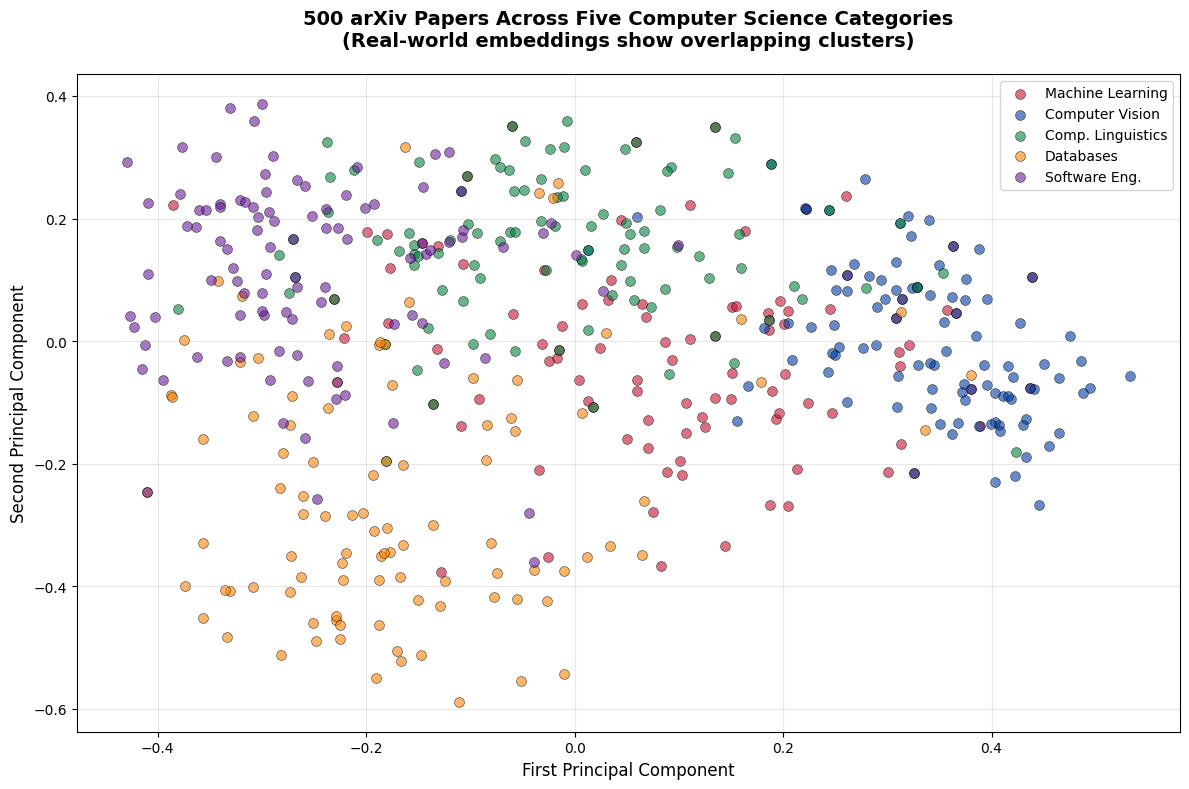

In [18]:
### Create the visualization
plt.figure(figsize=(12, 8))

### Define colors for different categories
colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A']
category_names = ['Machine Learning', 'Computer Vision', 'Comp. Linguistics', 'Databases', 'Software Eng.']
category_codes = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE']

### Plot each category
for i, (cat_code, cat_name, color) in enumerate(zip(category_codes, category_names, colors)):
    # Get papers from this category
    mask = df['category'] == cat_code
    cat_embeddings = embeddings_2d[mask]

    plt.scatter(cat_embeddings[:, 0], cat_embeddings[:, 1],
                c=color, label=cat_name, s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('500 arXiv Papers Across Five Computer Science Categories\n(Real-world embeddings show overlapping clusters)',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()